## Portfolio Optimization using OSQP Solver

In [1]:
!pip install kagglehub


**Goal**: Build optimal portfolio from Nifty 50 stocks

* Mean-Variance optimization
* Long only constraint
* Fully invested (weights sum to 1)

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import shutil
import os
import cvxpy as cp
from pathlib import Path


DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

Data Ingestion

Download Data

Data Source: Kaggle - Nifty 50 daily prices

Downloaded using Kaggle API

In [3]:
# 1. Download Data via KaggleHub
print("Downloading Nifty 50 data...")
cache_path = kagglehub.dataset_download("rohanrao/nifty50-stock-market-data")

# 2. Move to local folder (flattening structure)
source_path = Path(cache_path)
if source_path.is_file():
    shutil.copy2(source_path, DATA_DIR / source_path.name)
elif source_path.is_dir():
    for f in source_path.glob("**/*.csv"): # Recursive search
        shutil.copy2(f, DATA_DIR / f.name)


print("Reading CSV files...")
files = [
    f for f in DATA_DIR.glob("*.csv") 
    if "NIFTY50_all" not in f.name and "stock_metadata" not in f.name
]

print(f"Found {len(files)} files.")

df_list = []
for f in files:
    try:
        tmp = pd.read_csv(f)
        
        # Ensure consistent column names
        tmp.columns = [c.strip().lower() for c in tmp.columns]
        
        # Use filename as symbol if the column is missing
        if 'symbol' not in tmp.columns:
            tmp['symbol'] = f.stem.upper()
            
        df_list.append(tmp)
    except Exception as e:
        print(f"Skipping {f.name}: {e}")

raw_df = pd.concat(df_list, axis=0)

Reading CSV files...
Found 50 files.


C:\Users\Biswajit Kala\AppData\Local\Temp\ipykernel_15712\1720878790.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  raw_df = pd.concat(df_list, axis=0)


In [4]:
raw_df

,date,symbol,series,prev close,open,high,low,last,close,vwap,volume,turnover,trades,deliverable volume,%deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.00,959.00,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.00,885.00,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.00,887.00,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.00,929.00,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.00,980.00,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5301,2021-04-26,ZEEL,EQ,188.00,190.60,191.10,185.10,186.70,186.40,187.35,8542755,1.600451e+14,52374.0,2340188.0,0.2739
5302,2021-04-27,ZEEL,EQ,186.40,188.00,192.95,186.80,188.80,188.15,189.41,14247767,2.698636e+14,73673.0,5425957.0,0.3808
5303,2021-04-28,ZEEL,EQ,188.15,188.80,190.60,187.10,188.95,189.10,188.85,8429439,1.591917e+14,44056.0,2413974.0,0.2864
5304,2021-04-29,ZEEL,EQ,189.10,190.80,191.65,186.00,186.60,186.55,187.44,9483009,1.777471e+14,60932.0,2744472.0,0.2894


In [7]:
F=raw_df.to_csv("raw_df.csv", index=False)


In [8]:
import os
print(os.getcwd())

c:\Users\Biswajit Kala\Desktop\Industry Project\assignment 2


In [ ]:
l=set(raw_df['symbol'])

In [ ]:
len(l)

65

## Data Cleaning

### Filter 5 years

* Too old data = market conditions changed (different govt, policies, etc.)

* Too short = not enough data points for covariance estimation

* 5 years taken as it covers multiple market cycles (bull + bear)

* 2016-2021 includes demonetization, COVID crash, recovery - good stress test

In [ ]:
raw_df.columns = [c.strip().lower() for c in raw_df.columns]

raw_df['date'] = pd.to_datetime(raw_df['date'])
START_DATE = '2016-01-01'
print(f"Filtering for 5-year window ({START_DATE} onwards)...")
raw_df = raw_df[raw_df['date'] >= START_DATE]

Filtering for 5-year window (2016-01-01 onwards)...


In [ ]:
raw_df.describe(include='all')

,date,symbol,series,prev close,open,high,low,last,close,vwap,volume,turnover,trades,deliverable volume,%deliverble
count,64582,64582,64582,64582.000000,64582.000000,64582.000000,64582.000000,64582.000000,64582.000000,64582.000000,64582.0,6.458200e+04,6.458200e+04,6.458200e+04,64582.000000
unique,NaN,49,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64308.0,NaN,NaN,NaN,NaN
top,NaN,ADANIPORTS,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,702853.0,NaN,NaN,NaN,NaN
freq,NaN,1318,64582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
mean,2018-08-31 16:14:34.051593216,NaN,NaN,2236.422272,2239.236104,2267.907695,2207.485284,2236.649060,2236.998425,2237.653534,NaN,3.476478e+14,8.110436e+04,2.474930e+06,0.453286
min,2016-01-01 00:00:00,NaN,NaN,60.000000,59.400000,62.900000,50.000000,60.200000,60.000000,60.840000,NaN,8.818495e+11,1.950000e+02,2.860000e+02,0.029900
25%,2017-05-04 00:00:00,NaN,NaN,331.362500,331.712500,336.700000,325.800000,331.400000,331.412500,331.392500,NaN,1.015743e+14,3.313125e+04,3.983550e+05,0.316500
50%,2018-08-28 12:00:00,NaN,NaN,750.875000,751.000000,760.000000,741.225000,750.500000,751.000000,750.970000,NaN,1.959911e+14,5.817200e+04,1.251184e+06,0.457600
75%,2020-01-03 00:00:00,NaN,NaN,2063.525000,2067.237500,2091.500000,2040.000000,2065.450000,2064.187500,2066.972500,NaN,3.947338e+14,9.994400e+04,3.013276e+06,0.587100
max,2021-04-30 00:00:00,NaN,NaN,32861.950000,33399.950000,33480.000000,32468.100000,32849.000000,32861.950000,32975.240000,NaN,3.564334e+16,1.643015e+06,2.325307e+08,0.979700


In [ ]:
unique_symbols = raw_df['symbol'].unique()
unique_symbols.sort()

print(f"Total Unique Assets: {len(unique_symbols)}")

for ticker in unique_symbols:
    print(ticker)

Total Unique Assets: 49
ADANIPORTS
ASIANPAINT
AXISBANK
BAJAJ-AUTO
BAJAJFINSV
BAJFINANCE
BHARTIARTL
BPCL
BRITANNIA
CIPLA
COALINDIA
DRREDDY
EICHERMOT
GAIL
GRASIM
HCLTECH
HDFC
HDFCBANK
HEROMOTOCO
HINDALCO
HINDUNILVR
ICICIBANK
INDUSINDBK
INFY
IOC
ITC
JSWSTEEL
KOTAKBANK
LT
M&M
MARUTI
NESTLEIND
NTPC
ONGC
POWERGRID
RELIANCE
SBIN
SHREECEM
SUNPHARMA
TATAMOTORS
TATASTEEL
TCS
TECHM
TITAN
ULTRACEMCO
UPL
VEDL
WIPRO
ZEEL


In [ ]:
raw_df.isna().sum()

date                  0
symbol                0
series                0
prev close            0
open                  0
high                  0
low                   0
last                  0
close                 0
vwap                  0
volume                0
turnover              0
trades                0
deliverable volume    0
%deliverble           0
dtype: int64

In [ ]:
prices = raw_df.pivot_table(index='date', columns='symbol', values='close')
prices = prices.sort_index()

prices.head()

symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,...,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,UPL,VEDL,WIPRO,ZEEL
date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,267.55,878.75,449.90,2518.00,1983.80,6095.85,340.50,896.05,2986.40,655.35,...,401.90,257.40,2416.40,520.05,352.05,2824.00,440.35,91.65,556.45,432.90
2016-01-04,257.95,880.80,438.40,2483.35,1959.50,6052.45,326.80,891.45,2972.60,645.65,...,377.05,256.90,2369.60,516.40,351.40,2749.15,433.85,88.95,557.70,421.95
2016-01-05,255.70,900.65,436.45,2502.35,1946.00,5997.85,323.45,902.65,2966.70,640.85,...,374.45,274.30,2348.95,521.90,347.70,2733.05,435.30,92.40,556.90,425.05
2016-01-06,251.80,886.40,430.70,2485.50,1938.55,6107.25,322.20,912.30,3001.70,652.10,...,365.90,268.75,2381.60,525.10,347.85,2735.30,443.35,88.90,555.10,423.15
2016-01-07,245.00,872.35,409.25,2419.25,1927.05,6106.30,322.35,884.25,2946.55,637.45,...,343.55,249.90,2371.25,510.80,344.05,2667.70,417.40,81.15,549.85,415.40


In [ ]:
prices.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1318 entries, 2016-01-01 to 2021-04-30
Data columns (total 49 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ADANIPORTS  1318 non-null   float64
 1   ASIANPAINT  1318 non-null   float64
 2   AXISBANK    1318 non-null   float64
 3   BAJAJ-AUTO  1318 non-null   float64
 4   BAJAJFINSV  1318 non-null   float64
 5   BAJFINANCE  1318 non-null   float64
 6   BHARTIARTL  1318 non-null   float64
 7   BPCL        1318 non-null   float64
 8   BRITANNIA   1318 non-null   float64
 9   CIPLA       1318 non-null   float64
 10  COALINDIA   1318 non-null   float64
 11  DRREDDY     1318 non-null   float64
 12  EICHERMOT   1318 non-null   float64
 13  GAIL        1318 non-null   float64
 14  GRASIM      1318 non-null   float64
 15  HCLTECH     1318 non-null   float64
 16  HDFC        1318 non-null   float64
 17  HDFCBANK    1318 non-null   float64
 18  HEROMOTOCO  1318 non-null   float64
 19  HINDALCO 

In [ ]:
import numpy as np

# 1. Compute Daily LOG Returns
returns = np.log(prices / prices.shift(1)).dropna()

# 2. Annualize Parameters (252 trading days)
# Mu = Expected Annual Log Return
# Sigma = Annualized Covariance Matrix
mu = returns.mean().values * 252
sigma = returns.cov().values * 252
tickers = returns.columns.tolist()

print(f"Optimization Universe: {len(tickers)} Assets")
print(f"Avg Expected Return: {np.mean(mu):.2%}")
print(f"Avg Annual Risk: {np.mean(np.sqrt(np.diag(sigma))):.2%}")


Optimization Universe: 49 Assets
Avg Expected Return: 3.85%
Avg Annual Risk: 41.78%


In [ ]:
print(f"Dimensions: {prices.shape} (Rows x Assets)")
print(f"Date Range: {prices.index.min().date()} to {prices.index.max().date()}")

Dimensions: (1318, 49) (Rows x Assets)
Date Range: 2016-01-01 to 2021-04-30


In [ ]:
print("Dimensions of Returns Matrix:", returns.shape)

print("Dimensions of Mu Vector:",mu.shape)
print("Dimensions of Sigma Matrix:",sigma.shape)

Dimensions of Returns Matrix: (1317, 49)
Dimensions of Mu Vector: (49,)
Dimensions of Sigma Matrix: (49, 49)


#### Large γ → more aggressive (return seeking).
#### Small γ → conservative (risk minimizing).

The risk-free return is implicitly assumed to be 0

### Interpretation of \( \gamma \)

The objective balances **risk minimization** and **return maximization**:

Objective = Risk − (γ × Return)

- Small ( gamma ) → risk dominates → conservative portfolio  
- Large ( gamma ) → return dominates → aggressive portfolio  

Each value of ( gamma ) corresponds to one optimal portfolio on the **efficient frontier**.


In [ ]:
# Risk Aversion Parameters (Gamma)
gammas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

n_assets = len(tickers)
w = cp.Variable(n_assets)
gamma_param = cp.Parameter(nonneg=True)

# Objective: Minimize (0.5 * Risk - Gamma * Return)
port_ret = mu @ w
port_risk = cp.quad_form(w, sigma)
objective = cp.Minimize(0.5 * port_risk - gamma_param * port_ret)

# Constraints: Fully Invested, Long Only
constraints = [
    cp.sum(w) == 1,
    w >= 0
]

prob = cp.Problem(objective, constraints)
results = []

print("Running OSQP Solver...")
print("-" * 65)
print(f"{'Gamma':<6} | {'Return':<10} | {'Risk':<10} | {'Sharpe':<8} | {'Status'}")
print("-" * 65)

for g in gammas:
    gamma_param.value = g
    prob.solve(solver=cp.OSQP, verbose=False)   # ✅ Only change here
    
    if prob.status in ['optimal', 'optimal_inaccurate']:
        wt_clean = w.value.copy()
        wt_clean[wt_clean < 1e-4] = 0.0
        wt_clean = wt_clean / np.sum(wt_clean)
        
        p_ret = wt_clean @ mu
        p_vol = np.sqrt(wt_clean.T @ sigma @ wt_clean)
        sharpe = p_ret / p_vol
        
        s = pd.Series(wt_clean, index=tickers).sort_values(ascending=False)
        top3 = ", ".join([f"{i}({v:.0%})" for i, v in s.head(3).items()])
        
        results.append({
            "Gamma": g, "Return": p_ret, "Risk": p_vol, 
            "Sharpe": sharpe, "Top Holdings": top3
        })
        
        print(f"{g:<6} | {p_ret:.2%}     | {p_vol:.2%}     | {sharpe:.2f}     | {prob.status}")
    else:
        print(f"{g:<6} | FAILED     |            |          | {prob.status}")

df_res = pd.DataFrame(results).set_index("Gamma")


Running OSQP Solver...
-----------------------------------------------------------------
Gamma  | Return     | Risk       | Sharpe   | Status
-----------------------------------------------------------------
0.1    | 20.58%     | 17.56%     | 1.17     | optimal
0.5    | 29.48%     | 27.40%     | 1.08     | optimal
1.0    | 31.39%     | 31.69%     | 0.99     | optimal
2.0    | 32.85%     | 37.55%     | 0.87     | optimal
5.0    | 32.85%     | 37.55%     | 0.87     | optimal
10.0   | 32.85%     | 37.55%     | 0.87     | optimal


It solves a Markowitz portfolio optimization problem for multiple risk-aversion values (γ), computes the optimal portfolio for each γ using the OSQP solver, and reports return, risk, Sharpe ratio, and top holdings.

## Efficient Frontier

This code maps each stock to its industry and color, computes individual stock volatility from the covariance matrix, and creates a table showing each stock’s risk–return profile for analysis and visualization.

In [ ]:
# Industry mapping for color coding (used later in per-gamma sections)
industry_map = {
    'NESTLEIND': 'FMCG', 'HINDUNILVR': 'FMCG', 'BRITANNIA': 'FMCG', 'ITC': 'FMCG',
    'BAJAJFINSV': 'Finance', 'BAJFINANCE': 'Finance', 'HDFCBANK': 'Finance', 'ICICIBANK': 'Finance',
    'KOTAKBANK': 'Finance', 'AXISBANK': 'Finance', 'SBIN': 'Finance', 'INDUSINDBK': 'Finance', 'HDFC': 'Finance',
    'TITAN': 'Consumer', 'ASIANPAINT': 'Consumer', 'MARUTI': 'Auto', 'HEROMOTOCO': 'Auto',
    'BAJAJ-AUTO': 'Auto', 'EICHERMOT': 'Auto', 'MM': 'Auto', 'TATAMOTORS': 'Auto',
    'TCS': 'IT', 'INFY': 'IT', 'WIPRO': 'IT', 'HCLTECH': 'IT', 'TECHM': 'IT',
    'RELIANCE': 'Energy', 'ONGC': 'Energy', 'BPCL': 'Energy', 'IOC': 'Energy', 'GAIL': 'Energy',
    'POWERGRID': 'Power', 'NTPC': 'Power', 'COALINDIA': 'Power',
    'TATASTEEL': 'Metals', 'HINDALCO': 'Metals', 'JSWSTEEL': 'Metals', 'VEDL': 'Metals',
    'DRREDDY': 'Pharma', 'SUNPHARMA': 'Pharma', 'CIPLA': 'Pharma',
    'ADANIPORTS': 'Infra', 'LT': 'Infra', 'GRASIM': 'Infra', 'ULTRACEMCO': 'Cement', 'SHREECEM': 'Cement',
    'BHARTIARTL': 'Telecom', 'INFRATEL': 'Telecom', 'ZEEL': 'Media', 'UPL': 'Agri'
}

industry_colors = {
    'FMCG': '#2ecc71', 'Finance': '#3498db', 'Consumer': '#9b59b6', 'Auto': '#e74c3c',
    'IT': '#1abc9c', 'Energy': '#f39c12', 'Power': '#e67e22', 'Metals': '#95a5a6',
    'Pharma': '#d35400', 'Infra': '#8e44ad', 'Cement': '#7f8c8d', 'Telecom': '#16a085',
    'Media': '#c0392b', 'Agri': '#27ae60'
}

asset_vols = np.sqrt(np.diag(sigma))
# Individual stock risk-return profile
stock_stats = pd.DataFrame({
    'Stock': tickers,
    'Return': [f"{r:.2%}" for r in mu],
    'Risk': [f"{v:.2%}" for v in asset_vols]
}).sort_values('Stock').reset_index(drop=True)
stock_stats

,Stock,Return,Risk
0,ADANIPORTS,19.21%,37.30%
1,ASIANPAINT,20.28%,26.08%
2,AXISBANK,8.86%,39.02%
3,BAJAJ-AUTO,8.04%,26.58%
4,BAJAJFINSV,32.85%,37.55%
5,BAJFINANCE,-2.14%,108.39%
6,BHARTIARTL,8.71%,34.26%
7,BPCL,-14.42%,52.88%
8,BRITANNIA,2.76%,39.55%
9,CIPLA,6.29%,27.96%


The code computes optimal portfolios for many risk preferences and plots the efficient frontier, showing how portfolio risk and return trade off compared to individual stocks.

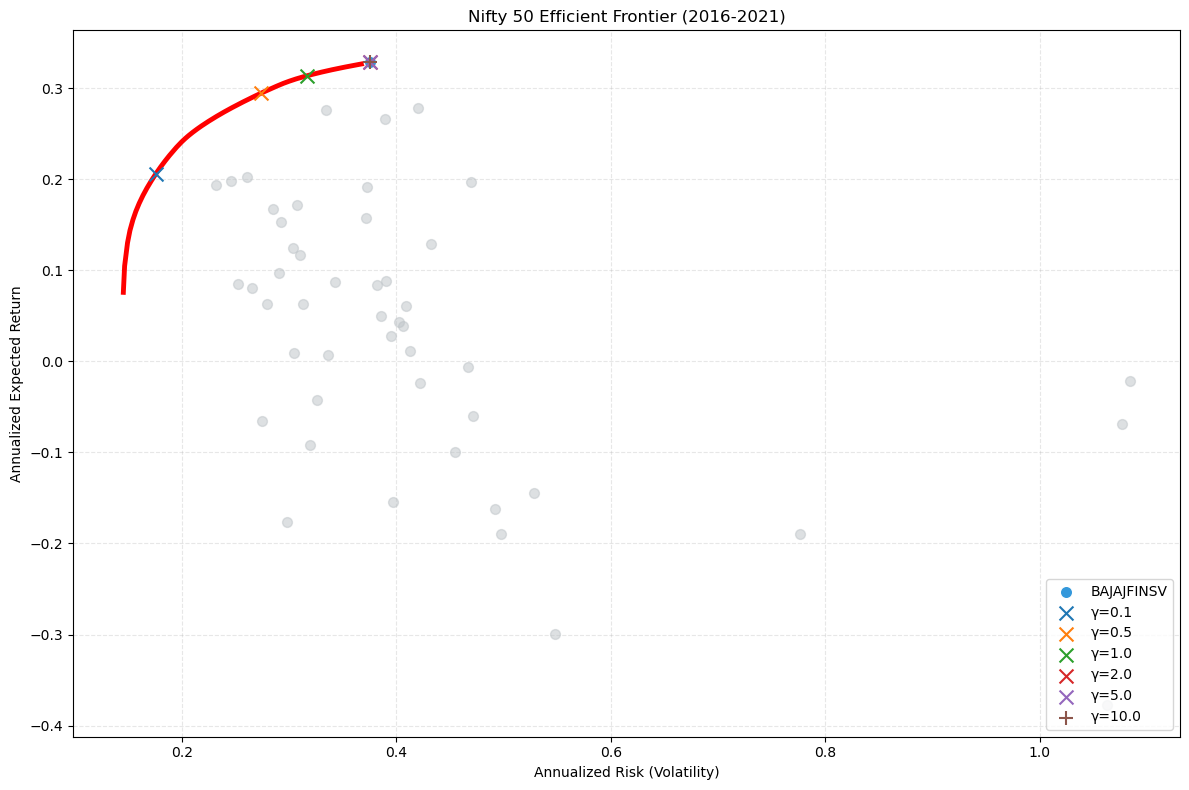

In [ ]:
marker_gammas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
gamma_range = np.unique(np.sort(np.concatenate([np.linspace(0.001, 20, 2000), marker_gammas])))

frontier_risks, frontier_returns = [], []
for g in gamma_range:
    gamma_param.value = g
    prob.solve(solver=cp.OSQP, verbose=False)
    if prob.status in ['optimal', 'optimal_inaccurate']:
        wt = np.maximum(w.value, 0); wt /= wt.sum()
        frontier_returns.append(wt @ mu)
        frontier_risks.append(np.sqrt(wt @ sigma @ wt))

# Color scheme for gamma markers
gamma_colors = {0.1: '#1f77b4', 0.5: '#ff7f0e', 1.0: '#2ca02c', 2.0: '#d62728', 5.0: '#9467bd', 10.0: '#8c564b'}

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(asset_vols, mu, color='#bdc3c7', alpha=0.5, s=50, zorder=2)  # Individual stocks
ax.plot(frontier_risks, frontier_returns, 'r-', lw=3.5, zorder=5)  # Frontier

# Highlight BAJAJFINSV separately (it overlaps with gamma=5,10)
bajaj_idx = tickers.index('BAJAJFINSV')
ax.scatter(asset_vols[bajaj_idx], mu[bajaj_idx], color='#3498db', s=80, zorder=6, edgecolor='white', lw=1, label='BAJAJFINSV')

# Gamma markers with color coding (smaller and thinner)
for g in marker_gammas:
    if g in df_res.index:
        marker = '+' if g == 10.0 else 'x'
        ax.scatter(df_res.loc[g, 'Risk'], df_res.loc[g, 'Return'], marker=marker, s=100, 
                   c=gamma_colors[g], zorder=10, lw=1.5, label=f'γ={g}')

ax.set(title="Nifty 50 Efficient Frontier (2016-2021)", xlabel="Annualized Risk (Volatility)", ylabel="Annualized Expected Return")
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Marks important portfolios (γ = 0.1, 0.5, 1, 2, 5, 10) with colored symbols.

These are the portfolios you previously computed.

## Optimal Portfolio Weights

In [ ]:
portfolio_results = []
for g in marker_gammas:
    gamma_param.value = g
    prob.solve(solver=cp.OSQP, verbose=False)
    if prob.status in ['optimal', 'optimal_inaccurate']:
        wt = np.maximum(w.value, 0); wt /= wt.sum()
        wt[wt < 1e-4] = 0  # Clean small weights
        weights_str = ", ".join([f"{t}({v:.0%})" for t, v in sorted(zip(tickers, wt), key=lambda x: -x[1]) if v > 0])
        portfolio_results.append({
            'Gamma': g,
            'Return': f"{wt @ mu:.2%}",
            'Risk': f"{np.sqrt(wt @ sigma @ wt):.2%}",
            'Portfolio Weights': weights_str
        })

pd.DataFrame(portfolio_results)

,Gamma,Return,Risk,Portfolio Weights
0,0.1,20.58%,17.56%,"HINDUNILVR(22%), NESTLEIND(21%), TITAN(12%), A..."
1,0.5,29.48%,27.40%,"BAJAJFINSV(48%), TITAN(32%), NESTLEIND(8%), TA..."
2,1.0,31.39%,31.69%,"BAJAJFINSV(72%), TITAN(25%), HINDALCO(3%)"
3,2.0,32.85%,37.55%,BAJAJFINSV(100%)
4,5.0,32.85%,37.55%,BAJAJFINSV(100%)
5,10.0,32.85%,37.55%,BAJAJFINSV(100%)


### Why These Stocks?
For each gamma value, we show:

**Efficient frontier plot** : with the gamma point marked and portfolio stocks highlighted

**Correlation heatmap** :(for diversified portfolios) showing why these stocks work together

**Conclusion**: explaining the solver's logic

**Key Insight**: As gamma increases, portfolio goes from diversified (many stocks) to concentrated (single stock)

Gamma = 0.1 (Safe Portfolio, Return = 20.58%, Risk = 17.56%)
Return and Risk of the portfolio stocks

In [ ]:
df = pd.DataFrame(portfolio_results)

current_gamma = 0.1
row_01 = df[df['Gamma'] == current_gamma].iloc[0]

row_01


Gamma                                                              0.1
Return                                                          20.58%
Risk                                                            17.56%
Portfolio Weights    HINDUNILVR(22%), NESTLEIND(21%), TITAN(12%), A...
Name: 0, dtype: object

In [ ]:
weights_str = row_01['Portfolio Weights']
print(weights_str)


HINDUNILVR(22%), NESTLEIND(21%), TITAN(12%), ASIANPAINT(11%), BAJAJFINSV(10%), POWERGRID(7%), DRREDDY(7%), TATASTEEL(6%), KOTAKBANK(2%), TECHM(1%), TCS(1%), CIPLA(0%)


In [ ]:
portfolio_stocks_01 = [
    item.split("(")[0].strip()
    for item in weights_str.split(",")
]

portfolio_stocks_01


['HINDUNILVR',
 'NESTLEIND',
 'TITAN',
 'ASIANPAINT',
 'BAJAJFINSV',
 'POWERGRID',
 'DRREDDY',
 'TATASTEEL',
 'KOTAKBANK',
 'TECHM',
 'TCS',
 'CIPLA']

In [ ]:
current_gamma = 0.1


stock_stats[stock_stats['Stock'].isin(portfolio_stocks_01)]

,Stock,Return,Risk
1,ASIANPAINT,20.28%,26.08%
4,BAJAJFINSV,32.85%,37.55%
9,CIPLA,6.29%,27.96%
11,DRREDDY,9.71%,29.04%
20,HINDUNILVR,19.34%,23.21%
27,KOTAKBANK,16.79%,28.55%
31,NESTLEIND,19.83%,24.62%
34,POWERGRID,8.52%,25.22%
40,TATASTEEL,26.61%,38.92%
41,TCS,4.37%,40.25%


***Efficient Frontier Plot:*** 

 Cross marker shows gamma=0.1 position. Portfolio stocks are color-coded by industry with labels. Grey dots = stocks not in portfolio.

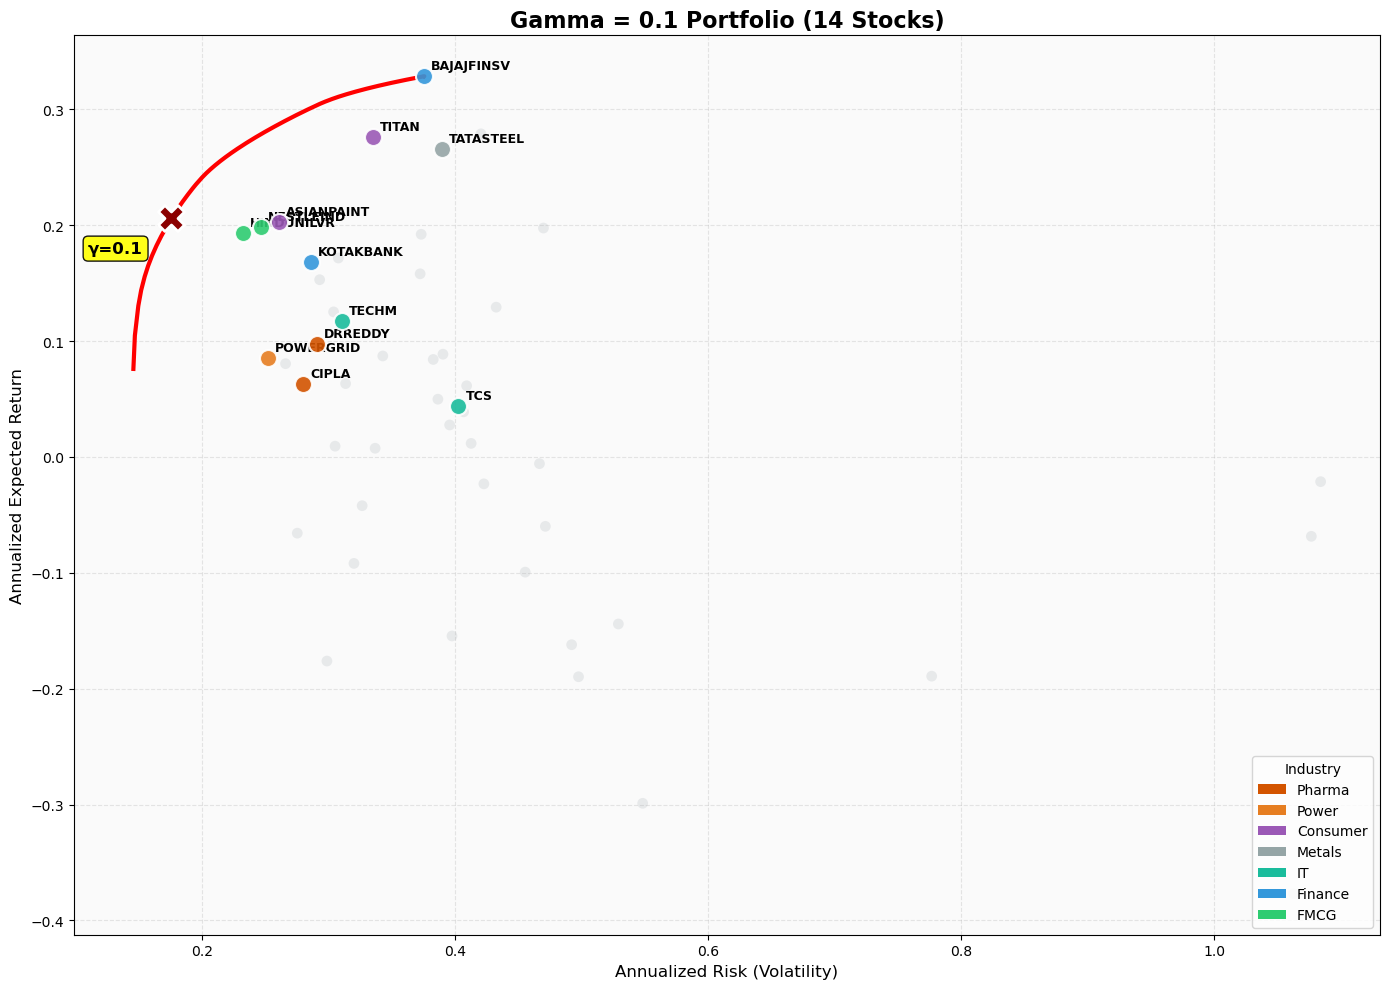

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

# Non-portfolio stocks in grey (no labels)
for i, ticker in enumerate(tickers):
    if ticker not in portfolio_stocks_01:
        ax.scatter(asset_vols[i], mu[i], color='#bdc3c7', alpha=0.3, s=60, edgecolor='none')

# Portfolio stocks with industry colors + labels
for i, ticker in enumerate(tickers):
    if ticker in portfolio_stocks_01:
        industry = industry_map.get(ticker, 'Other')
        color = industry_colors.get(industry, '#bdc3c7')
        ax.scatter(asset_vols[i], mu[i], color=color, alpha=0.9, s=150, edgecolor='white', linewidth=1.5, zorder=5)
        ax.annotate(ticker, (asset_vols[i], mu[i]), xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, fontweight='bold')

# Efficient Frontier curve
ax.plot(frontier_risks, frontier_returns, 'r-', linewidth=3, label='Efficient Frontier', zorder=3)

# Cross marker for gamma=0.1
ax.scatter(df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return'], 
           marker='X', s=350, c='darkred', zorder=10, edgecolor='white', linewidth=2)
ax.annotate(f"γ={current_gamma}", (df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return']), 
            xytext=(-60, -25), textcoords='offset points', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.9))

# Legend for industries present in portfolio
from matplotlib.patches import Patch
portfolio_industries = set(industry_map.get(s, 'Other') for s in portfolio_stocks_01)
legend_elements = [Patch(facecolor=industry_colors[ind], label=ind) for ind in portfolio_industries if ind in industry_colors]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Industry')

ax.set_title(f"Gamma = {current_gamma} Portfolio (14 Stocks)", fontsize=16, fontweight='bold')
ax.set_xlabel("Annualized Risk (Volatility)", fontsize=12)
ax.set_ylabel("Annualized Expected Return", fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

***Correlation Heatmap:***

 Lower correlation between stocks = better diversification = lower portfolio risk

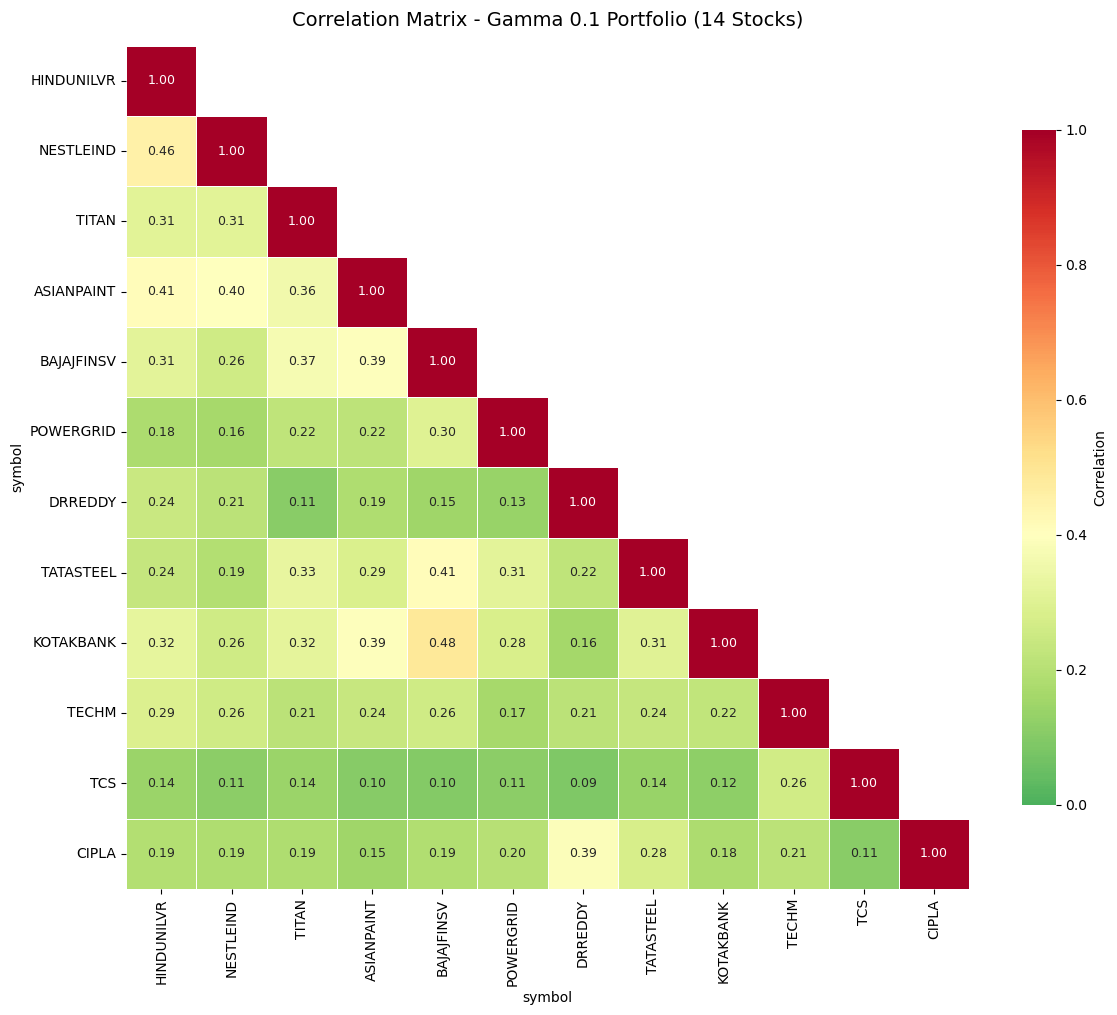

Average Pairwise Correlation: 0.24


In [ ]:
corr_matrix_01 = returns[portfolio_stocks_01].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_01, dtype=bool), k=1)
sns.heatmap(corr_matrix_01, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            mask=mask, vmin=0, vmax=1, center=0.4,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})

ax.set_title('Correlation Matrix - Gamma 0.1 Portfolio (14 Stocks)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Average correlation
mask_avg = np.ones_like(corr_matrix_01, dtype=bool)
np.fill_diagonal(mask_avg, False)
avg_corr_01 = corr_matrix_01.values[mask_avg].mean()
print(f"Average Pairwise Correlation: {avg_corr_01:.2f}")

The efficient frontier shows optimal risk–return combinations, and the point at γ = 0.1 lies on the low-risk side, indicating stable and moderate returns.
Instead of concentrating on one aggressive stock, the solver selects 12 stocks across multiple sectors to achieve diversification.
The correlation heatmap shows low to moderate correlations (0.1–0.4), meaning stocks do not move together strongly, which reduces overall risk.
Thus, the optimizer penalizes risk heavily at low gamma and spreads investments to smooth fluctuations while maintaining reasonable returns.

## Gamma = 0.5 (Moderate Portfolio, Return = 29.48%, Risk = 27.40%)

**Return and Risk of the portfolio stocks**

In [ ]:
df = pd.DataFrame(portfolio_results)

current_gamma = 0.5
row_02 = df[df['Gamma'] == current_gamma].iloc[0]

row_02


Gamma                                                              0.5
Return                                                          29.48%
Risk                                                            27.40%
Portfolio Weights    BAJAJFINSV(48%), TITAN(32%), NESTLEIND(8%), TA...
Name: 1, dtype: object

In [ ]:
weights_str = row_02['Portfolio Weights']
print(weights_str)


BAJAJFINSV(48%), TITAN(32%), NESTLEIND(8%), TATASTEEL(7%), HINDALCO(6%)


In [ ]:
portfolio_stocks_02 = [
    item.split("(")[0].strip()
    for item in weights_str.split(",")
]

portfolio_stocks_02

['BAJAJFINSV', 'TITAN', 'NESTLEIND', 'TATASTEEL', 'HINDALCO']

In [ ]:
current_gamma = 0.5


stock_stats[stock_stats['Stock'].isin(portfolio_stocks_02)]

,Stock,Return,Risk
4,BAJAJFINSV,32.85%,37.55%
19,HINDALCO,27.87%,42.03%
31,NESTLEIND,19.83%,24.62%
40,TATASTEEL,26.61%,38.92%
43,TITAN,27.63%,33.50%


***Efficient Frontier Plot:*** 

 Cross marker shows gamma=0.5 position. Portfolio stocks are color-coded by industry with labels. Grey dots = stocks not in portfolio.

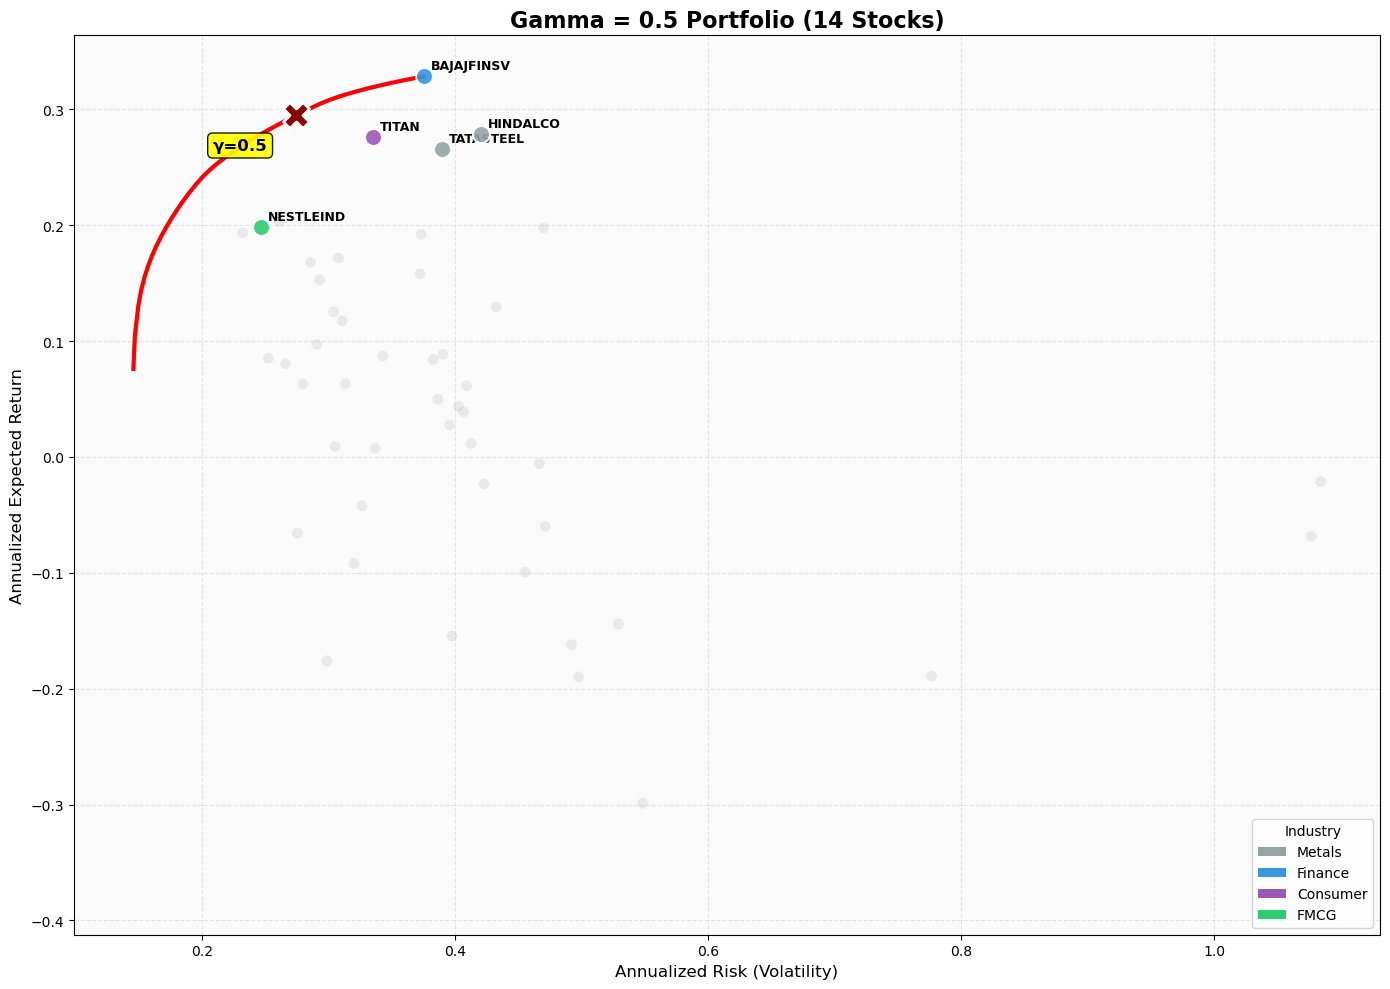

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

# Non-portfolio stocks in grey (no labels)
for i, ticker in enumerate(tickers):
    if ticker not in portfolio_stocks_02:
        ax.scatter(asset_vols[i], mu[i], color='#bdc3c7', alpha=0.3, s=60, edgecolor='none')

# Portfolio stocks with industry colors + labels
for i, ticker in enumerate(tickers):
    if ticker in portfolio_stocks_02:
        industry = industry_map.get(ticker, 'Other')
        color = industry_colors.get(industry, '#bdc3c7')
        ax.scatter(asset_vols[i], mu[i], color=color, alpha=0.9, s=150, edgecolor='white', linewidth=1.5, zorder=5)
        ax.annotate(ticker, (asset_vols[i], mu[i]), xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, fontweight='bold')

# Efficient Frontier curve
ax.plot(frontier_risks, frontier_returns, 'r-', linewidth=3, label='Efficient Frontier', zorder=3)

# Cross marker for gamma=0.1
ax.scatter(df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return'], 
           marker='X', s=350, c='darkred', zorder=10, edgecolor='white', linewidth=2)
ax.annotate(f"γ={current_gamma}", (df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return']), 
            xytext=(-60, -25), textcoords='offset points', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.9))

# Legend for industries present in portfolio
from matplotlib.patches import Patch
portfolio_industries = set(industry_map.get(s, 'Other') for s in portfolio_stocks_02)
legend_elements = [Patch(facecolor=industry_colors[ind], label=ind) for ind in portfolio_industries if ind in industry_colors]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Industry')

ax.set_title(f"Gamma = {current_gamma} Portfolio (14 Stocks)", fontsize=16, fontweight='bold')
ax.set_xlabel("Annualized Risk (Volatility)", fontsize=12)
ax.set_ylabel("Annualized Expected Return", fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

***Correlation Heatmap:***

 Lower correlation between stocks = better diversification = lower portfolio risk

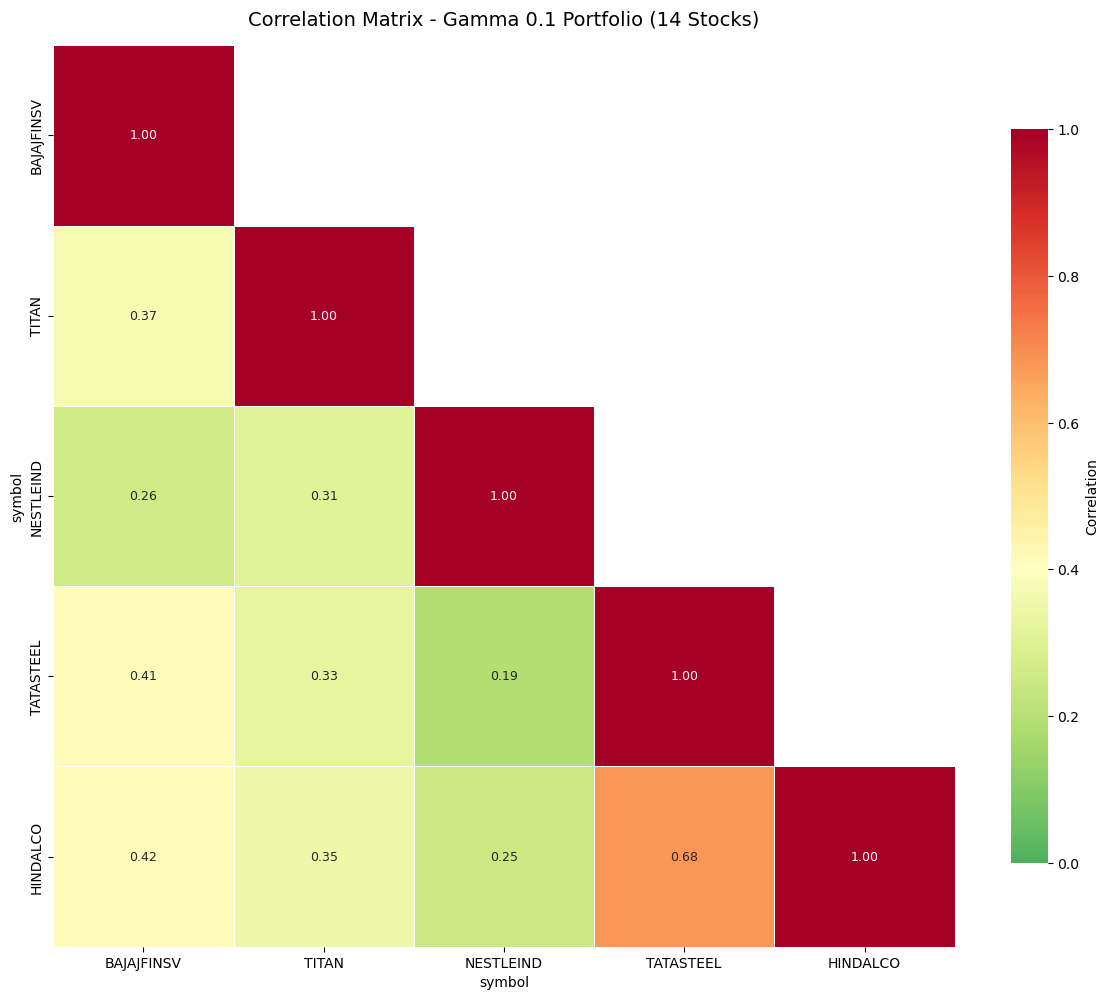

Average Pairwise Correlation: 0.36


In [ ]:
corr_matrix_01 = returns[portfolio_stocks_02].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_01, dtype=bool), k=1)
sns.heatmap(corr_matrix_01, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            mask=mask, vmin=0, vmax=1, center=0.4,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})

ax.set_title('Correlation Matrix - Gamma 0.1 Portfolio (14 Stocks)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Average correlation
mask_avg = np.ones_like(corr_matrix_01, dtype=bool)
np.fill_diagonal(mask_avg, False)
avg_corr_01 = corr_matrix_01.values[mask_avg].mean()
print(f"Average Pairwise Correlation: {avg_corr_01:.2f}")

**conclusion :** The efficient frontier point at γ = 0.5 shifts slightly rightward, indicating acceptance of higher risk in exchange for higher expected return.
Compared to γ = 0.1, the portfolio becomes more concentrated, with stronger weight on high-performing stocks like BAJAJFINSV, TITAN, and metal stocks.
The correlation heatmap shows some moderate correlations (e.g., between metal stocks), meaning diversification is reduced but not eliminated.
Overall, the solver balances risk and return by allowing selective concentration while still avoiding excessive exposure to highly correlated stocks.

# Gamma = 1.0 (Moderate Portfolio, Return = 31.39%, Risk = 31.69%)

**Return and Risk of the portfolio stocks**

In [ ]:
df = pd.DataFrame(portfolio_results)

current_gamma = 1.0
row_03 = df[df['Gamma'] == current_gamma].iloc[0]

row_03


Gamma                                                      1.0
Return                                                  31.39%
Risk                                                    31.69%
Portfolio Weights    BAJAJFINSV(72%), TITAN(25%), HINDALCO(3%)
Name: 2, dtype: object

In [ ]:
weights_str = row_03['Portfolio Weights']
print(weights_str)


BAJAJFINSV(72%), TITAN(25%), HINDALCO(3%)


In [ ]:
portfolio_stocks_03 = [
    item.split("(")[0].strip()
    for item in weights_str.split(",")
]

portfolio_stocks_03

['BAJAJFINSV', 'TITAN', 'HINDALCO']

In [ ]:
current_gamma = 1.0


stock_stats[stock_stats['Stock'].isin(portfolio_stocks_03)]

,Stock,Return,Risk
4,BAJAJFINSV,32.85%,37.55%
19,HINDALCO,27.87%,42.03%
43,TITAN,27.63%,33.50%


***Efficient Frontier Plot:*** 

 Cross marker shows gamma=1.0 position. Portfolio stocks are color-coded by industry with labels. Grey dots = stocks not in portfolio.

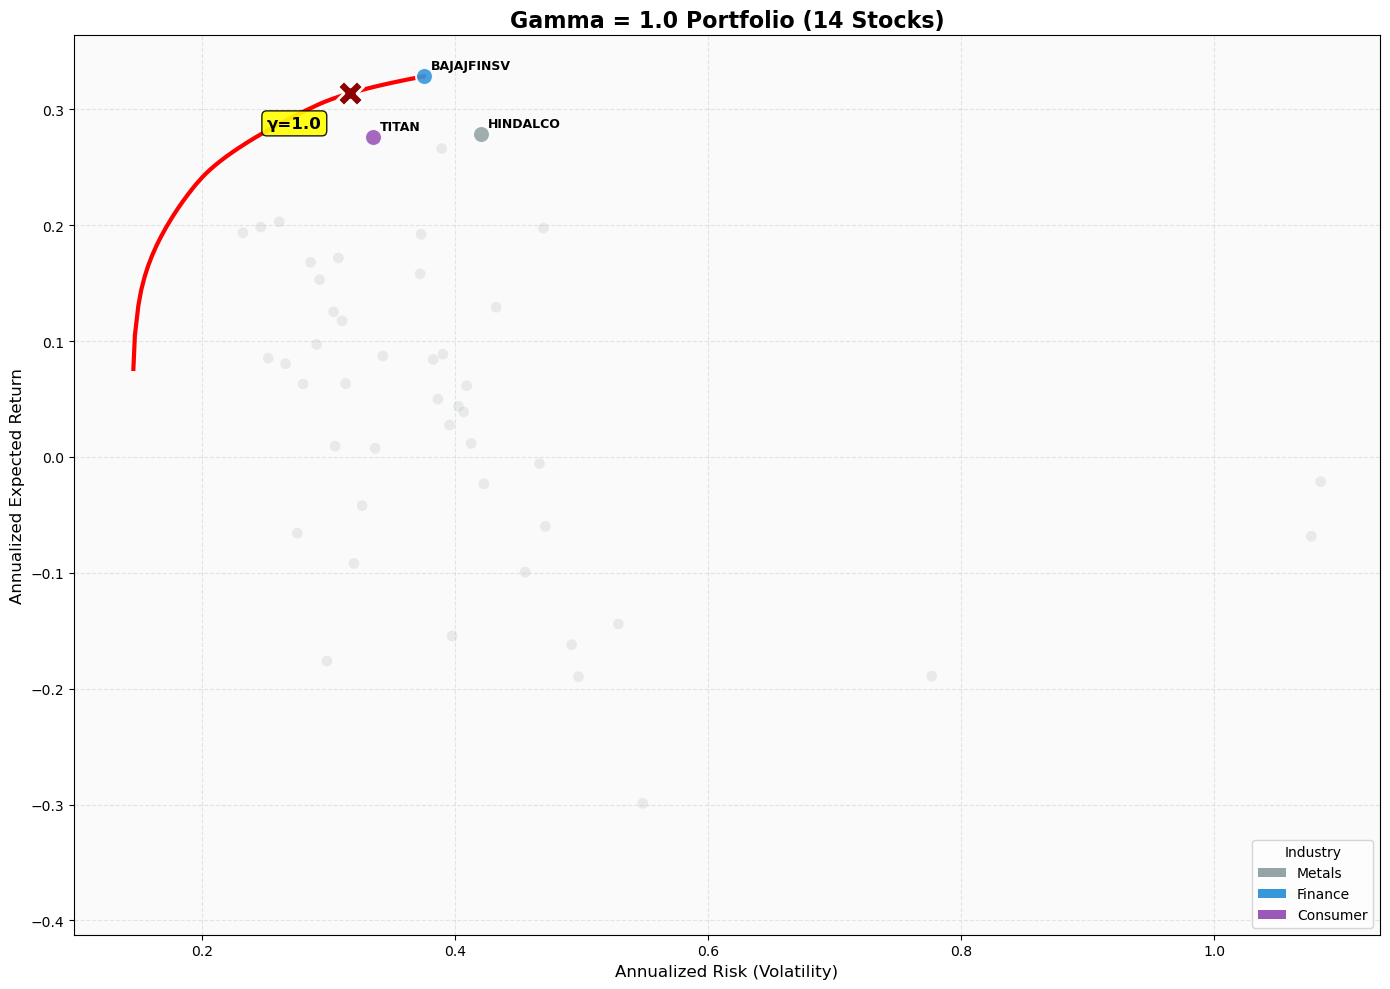

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

# Non-portfolio stocks in grey (no labels)
for i, ticker in enumerate(tickers):
    if ticker not in portfolio_stocks_03:
        ax.scatter(asset_vols[i], mu[i], color='#bdc3c7', alpha=0.3, s=60, edgecolor='none')

# Portfolio stocks with industry colors + labels
for i, ticker in enumerate(tickers):
    if ticker in portfolio_stocks_03:
        industry = industry_map.get(ticker, 'Other')
        color = industry_colors.get(industry, '#bdc3c7')
        ax.scatter(asset_vols[i], mu[i], color=color, alpha=0.9, s=150, edgecolor='white', linewidth=1.5, zorder=5)
        ax.annotate(ticker, (asset_vols[i], mu[i]), xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, fontweight='bold')

# Efficient Frontier curve
ax.plot(frontier_risks, frontier_returns, 'r-', linewidth=3, label='Efficient Frontier', zorder=3)

# Cross marker for gamma=0.1
ax.scatter(df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return'], 
           marker='X', s=350, c='darkred', zorder=10, edgecolor='white', linewidth=2)
ax.annotate(f"γ={current_gamma}", (df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return']), 
            xytext=(-60, -25), textcoords='offset points', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.9))

# Legend for industries present in portfolio
from matplotlib.patches import Patch
portfolio_industries = set(industry_map.get(s, 'Other') for s in portfolio_stocks_03)
legend_elements = [Patch(facecolor=industry_colors[ind], label=ind) for ind in portfolio_industries if ind in industry_colors]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Industry')

ax.set_title(f"Gamma = {current_gamma} Portfolio (14 Stocks)", fontsize=16, fontweight='bold')
ax.set_xlabel("Annualized Risk (Volatility)", fontsize=12)
ax.set_ylabel("Annualized Expected Return", fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

***Correlation Heatmap:***

 Lower correlation between stocks = better diversification = lower portfolio risk

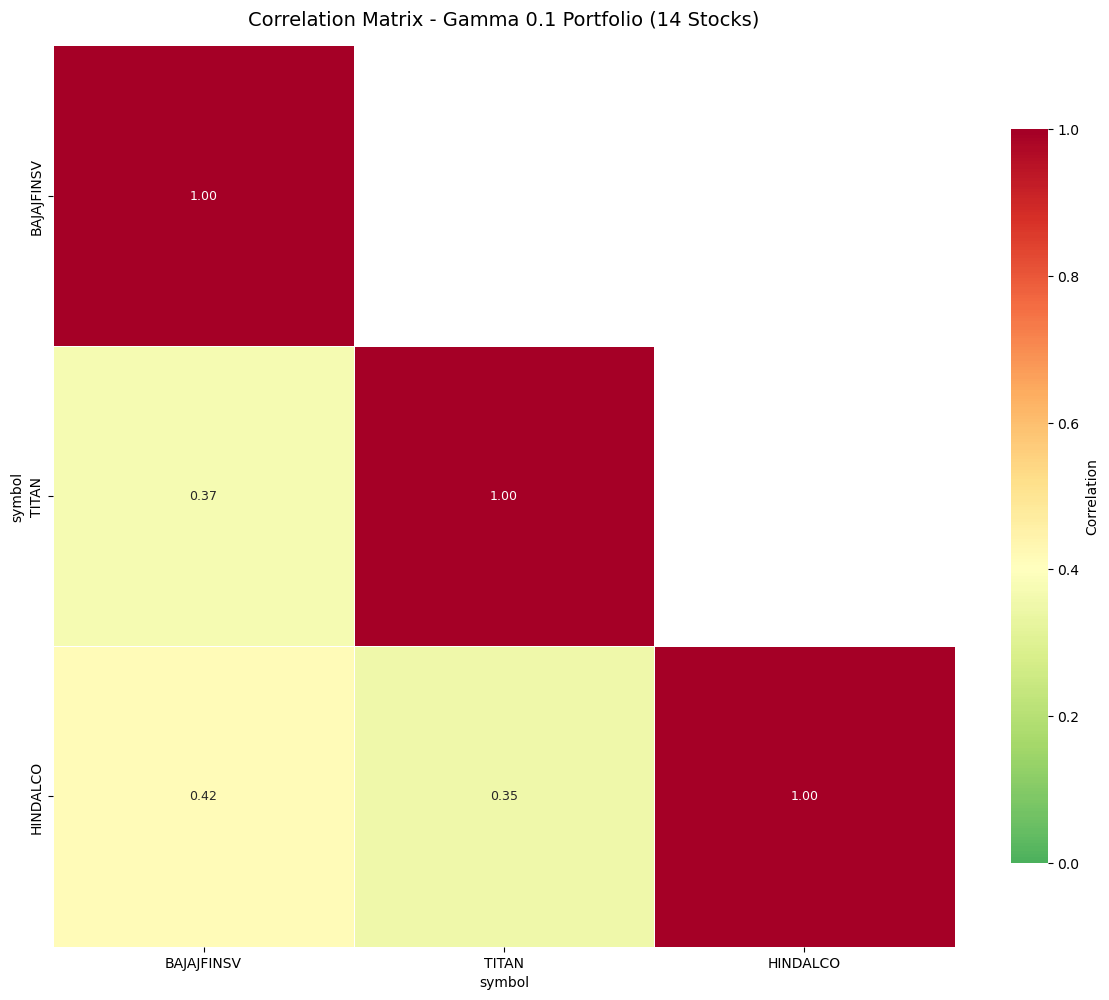

Average Pairwise Correlation: 0.38


In [ ]:
corr_matrix_01 = returns[portfolio_stocks_03].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_01, dtype=bool), k=1)
sns.heatmap(corr_matrix_01, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            mask=mask, vmin=0, vmax=1, center=0.4,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})

ax.set_title('Correlation Matrix - Gamma 0.1 Portfolio (14 Stocks)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Average correlation
mask_avg = np.ones_like(corr_matrix_01, dtype=bool)
np.fill_diagonal(mask_avg, False)
avg_corr_01 = corr_matrix_01.values[mask_avg].mean()
print(f"Average Pairwise Correlation: {avg_corr_01:.2f}")

**conclusion** At γ = 1.0, the efficient frontier point moves further right, showing that the optimizer is willing to take higher risk to achieve higher returns.
The portfolio becomes more concentrated, mainly selecting high-return stocks such as BAJAJFINSV, TITAN, and HINDALCO.
The correlation heatmap shows moderate correlations among the selected stocks, indicating reduced diversification compared to lower gamma values.
Overall, the solver prioritizes return over risk at γ = 1.0, allowing concentration in strong performers while still controlling extreme correlation risk.

## # Gamma = 2.0 (Moderate Portfolio, Return = 32.85%, Risk = 37.55%)

**Return and Risk of the portfolio stocks**

In [ ]:
df = pd.DataFrame(portfolio_results)

current_gamma = 2.0
row_04 = df[df['Gamma'] == current_gamma].iloc[0]

row_04


Gamma                             2.0
Return                         32.85%
Risk                           37.55%
Portfolio Weights    BAJAJFINSV(100%)
Name: 3, dtype: object

In [ ]:
weights_str = row_04['Portfolio Weights']
print(weights_str)


BAJAJFINSV(100%)


In [ ]:
portfolio_stocks_04 = [
    item.split("(")[0].strip()
    for item in weights_str.split(",")
]

portfolio_stocks_04

['BAJAJFINSV']

In [ ]:
current_gamma = 2.0


stock_stats[stock_stats['Stock'].isin(portfolio_stocks_04)]

,Stock,Return,Risk
4,BAJAJFINSV,32.85%,37.55%


***Efficient Frontier Plot:*** 

 Cross marker shows gamma=1.0 position. Portfolio stocks are color-coded by industry with labels. Grey dots = stocks not in portfolio.

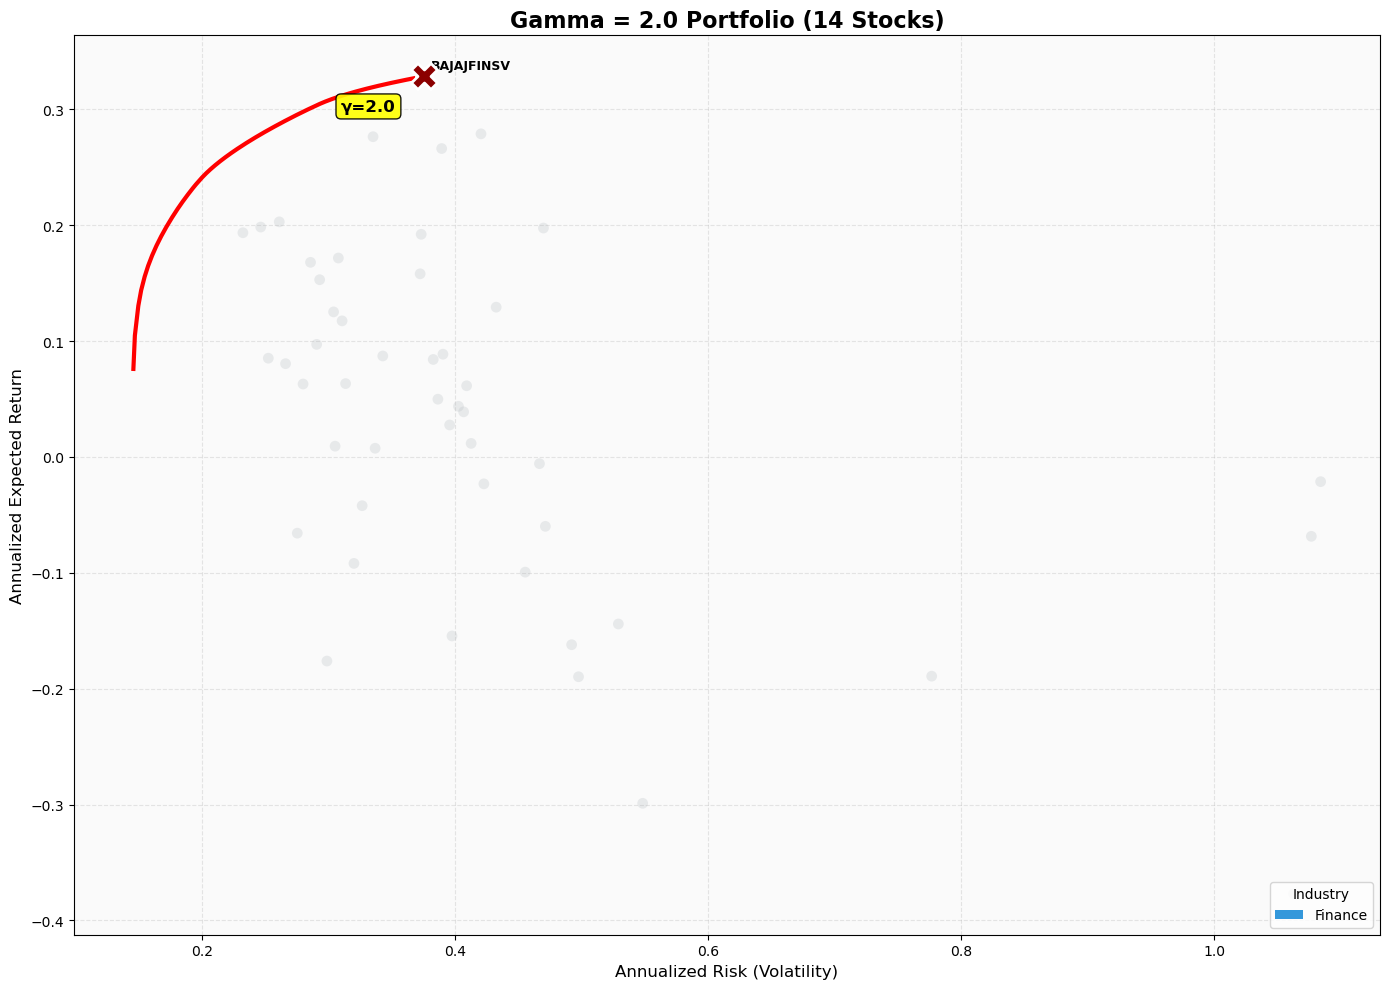

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

# Non-portfolio stocks in grey (no labels)
for i, ticker in enumerate(tickers):
    if ticker not in portfolio_stocks_04:
        ax.scatter(asset_vols[i], mu[i], color='#bdc3c7', alpha=0.3, s=60, edgecolor='none')

# Portfolio stocks with industry colors + labels
for i, ticker in enumerate(tickers):
    if ticker in portfolio_stocks_04:
        industry = industry_map.get(ticker, 'Other')
        color = industry_colors.get(industry, '#bdc3c7')
        ax.scatter(asset_vols[i], mu[i], color=color, alpha=0.9, s=150, edgecolor='white', linewidth=1.5, zorder=5)
        ax.annotate(ticker, (asset_vols[i], mu[i]), xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, fontweight='bold')

# Efficient Frontier curve
ax.plot(frontier_risks, frontier_returns, 'r-', linewidth=3, label='Efficient Frontier', zorder=3)

# Cross marker for gamma=0.1
ax.scatter(df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return'], 
           marker='X', s=350, c='darkred', zorder=10, edgecolor='white', linewidth=2)
ax.annotate(f"γ={current_gamma}", (df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return']), 
            xytext=(-60, -25), textcoords='offset points', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.9))

# Legend for industries present in portfolio
from matplotlib.patches import Patch
portfolio_industries = set(industry_map.get(s, 'Other') for s in portfolio_stocks_04)
legend_elements = [Patch(facecolor=industry_colors[ind], label=ind) for ind in portfolio_industries if ind in industry_colors]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Industry')

ax.set_title(f"Gamma = {current_gamma} Portfolio (14 Stocks)", fontsize=16, fontweight='bold')
ax.set_xlabel("Annualized Risk (Volatility)", fontsize=12)
ax.set_ylabel("Annualized Expected Return", fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

***Correlation Heatmap:***

 Lower correlation between stocks = better diversification = lower portfolio risk

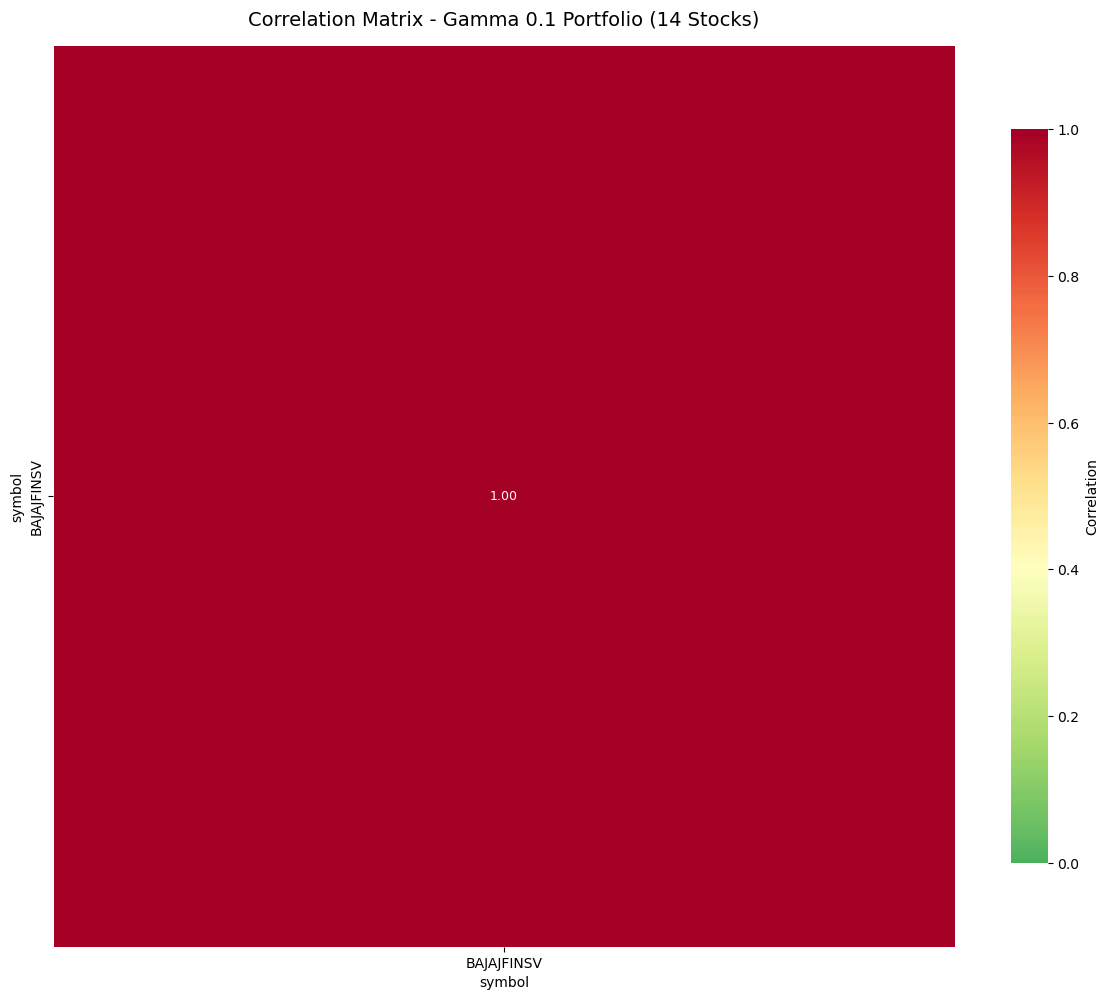

Average Pairwise Correlation: nan


C:\Users\Biswajit Kala\AppData\Local\Temp\ipykernel_28588\1061364167.py:18: RuntimeWarning: Mean of empty slice.
  avg_corr_01 = corr_matrix_01.values[mask_avg].mean()
c:\Users\Biswajit Kala\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
corr_matrix_01 = returns[portfolio_stocks_04].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_01, dtype=bool), k=1)
sns.heatmap(corr_matrix_01, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            mask=mask, vmin=0, vmax=1, center=0.4,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})

ax.set_title('Correlation Matrix - Gamma 0.1 Portfolio (14 Stocks)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Average correlation
mask_avg = np.ones_like(corr_matrix_01, dtype=bool)
np.fill_diagonal(mask_avg, False)
avg_corr_01 = corr_matrix_01.values[mask_avg].mean()
print(f"Average Pairwise Correlation: {avg_corr_01:.2f}")

**conclusion :** At γ = 2.0, the efficient frontier point moves to the far right, indicating very high risk tolerance in pursuit of maximum return.
The portfolio becomes fully concentrated in a single stock (BAJAJFINSV), as it offers the highest risk-adjusted return at this gamma level.
The correlation heatmap collapses to one asset, showing that diversification is completely abandoned.
Overall, the solver prioritizes return almost entirely over risk at γ = 2.0, resulting in a highly aggressive, single-stock portfolio.